In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("train.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: ylabel='Fare'>

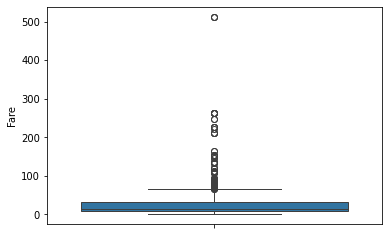

In [7]:
import seaborn as sns
sns.boxplot(data=df,y="Fare")

In [8]:
Q1=df.Fare.quantile(0.25)
Q3=df.Fare.quantile(0.75)
IQR=Q3-Q1
LL=Q1-1.5*IQR
HL=Q3+1.5*IQR

In [9]:
Q1,Q3,LL,HL

(7.9104, 31.0, -26.724, 65.6344)

In [10]:
detect outline

SyntaxError: invalid syntax (<ipython-input-10-109bc99eb487>, line 1)

In [13]:
df[(df["Fare"]<LL)|(df["Fare"]>HL)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S


In [14]:
df=df[(df["Fare"]<LL)|(df["Fare"]>HL)]

<Axes: ylabel='Fare'>

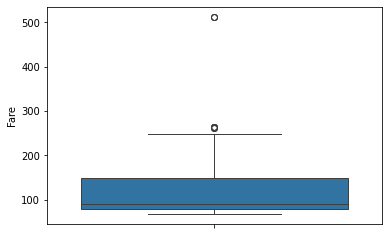

In [15]:
sns.boxplot(df.Fare)

<Axes: >

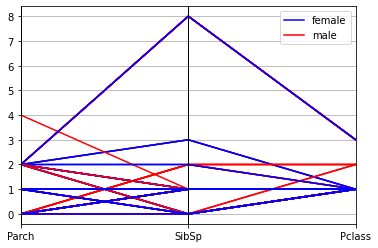

In [17]:
pd.plotting.parallel_coordinates(df,"Sex",["Parch","SibSp","Pclass"],color=["blue","red"])

In [18]:
df=pd.read_csv("auto-mpg.csv")

In [19]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

<Axes: >

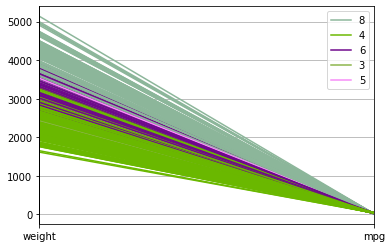

In [20]:
pd.plotting.parallel_coordinates(df,"cylinders",["weight","mpg"])

In [21]:
pd.crosstab(df.cylinders,df.origin,margins=True)

origin,1,2,3,All
cylinders,,,,
3,0,0,4,4
4,72,63,69,204
5,0,3,0,3
6,74,4,6,84
8,103,0,0,103
All,249,70,79,398


In [22]:
df[df["horsepower"]!="?"]["horsepower"].astype("int").mean()

104.46938775510205

In [23]:
df["horsepower"]=df["horsepower"].replace("?",104)

In [25]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [26]:
df["horsepower"]=df["horsepower"].astype("int")

In [27]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int32
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [28]:
import pandas as pd
import numpy as np

In [29]:
df1=pd.DataFrame({"A":[1,2],"B":[3,4]})
df2=pd.DataFrame({"A":[5,6],"B":[7,8]})

In [33]:
pd.concat((df1,df2))

,A,B
0,1,3
1,2,4
0,5,7
1,6,8


In [31]:
df2

,A,B
0,5,7
1,6,8


In [36]:
pd.concat((df1,df2),axis=0),ignore_index=True)

SyntaxError: unmatched ')' (<ipython-input-36-1dabe091503b>, line 1)

In [37]:
pd.concat((df1,df2),axis=1,ignore_index=False,keys=["df1","df2"])

df1    df2   
    A  B   A  B
0   1  3   5  7
1   2  4   6  8

In [38]:
df1=pd.DataFrame({"A":[1,2],"B":[3,4]})
df2=pd.DataFrame({"C":[5,6],"B":[7,8]})

In [39]:
pd.concat((df1,df2))

,A,B,C
0,1.0,3,NaN
1,2.0,4,NaN
0,NaN,7,5.0
1,NaN,8,6.0


In [40]:
pd.concat((df1,df2),axis=1)

,A,B,C,B
0,1,3,5,7
1,2,4,6,8


In [41]:
df1=pd.DataFrame({"X":[1,2],"Y":[3,4]})
df2=pd.DataFrame({"C":[5,6],"B":[7,8]})

In [42]:
pd.concat((df1,df2),join="inner")

""
0
1
0
1


In [44]:
df1=pd.DataFrame({"sub":["python","fsd","coa","dm","toc",],"fac":["vha","psp","vby","ddp","dps"],"id":[1,2,3,4,5]})
df2=pd.DataFrame({"id":[1,2,3,4,6],"score":[10,9,10,8,9]})

In [47]:
pd.merge(df1,df2,on="id",how="inner")

,sub,fac,id,score
0,python,vha,1,10
1,fsd,psp,2,9
2,coa,vby,3,10
3,dm,ddp,4,8


In [48]:
pd.merge(df1,df2,on="id",how="left")

,sub,fac,id,score
0,python,vha,1,10.0
1,fsd,psp,2,9.0
2,coa,vby,3,10.0
3,dm,ddp,4,8.0
4,toc,dps,5,NaN
